# 🏠 Análise de Preços de Imóveis no Airbnb no Rio de Janeiro

## 📌 Contexto do Projeto

Fomos contratados por uma plataforma de aluguel de imóveis para analisar dados do Airbnb na cidade do Rio de Janeiro.

O objetivo é compreender o comportamento dos preços dos imóveis disponíveis na plataforma, bem como identificar padrões e fatores que influenciam esses valores.

Essas informações são essenciais para apoiar decisões estratégicas, como definição de preços, posicionamento de imóveis e melhoria da competitividade na plataforma.

---

## 🎯 Objetivo do Projeto

Realizar uma análise exploratória dos dados do Airbnb no Rio de Janeiro, com o intuito de:

Identificar os principais fatores que influenciam o preço dos imóveis
Analisar a variação de preços entre diferentes regiões e tipos de acomodação
Explorar padrões nos dados que possam gerar insights relevantes para o negócio
Preparar os dados para possíveis aplicações em modelos preditivos

---

## 📌 Perguntas de Negócio

* Como os imóveis estão distribuídos geograficamente e por volume?
* Qual a mediana de preço por bairro e como o volume de anúncios influencia esse valor?
* Qual é a tipologia de imóvel predominante em cada região?
* Imóveis com mais avaliações tendem a ser mais baratos?
* Qual a disponibilidade média dos imóveis ao longo do ano por região?


## 📥 Entendimento dos Dados

In [ ]:
import pandas as pd

df = pd.read_csv('listings.csv')

### 🔹 Visualização inicial dos dados

In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,821198084644106078,Bright and Peaceful Leblon Loft,84350716,Katrina,NaN,Leblon,-22.982818,-43.222457,Entire home/apt,580.0,2,86,2025-09-19,2.72,1,82,40,NaN
1,821198370698658112,Copacabana 100% reformado.,4347269,Patrick,NaN,Copacabana,-22.984090,-43.191770,Entire home/apt,1900.0,5,0,NaN,NaN,2,364,0,NaN
2,821200521820144734,hambiente familia,499903412,Vanessa,NaN,Pavuna,-22.814911,-43.379011,Entire home/apt,700.0,1,0,NaN,NaN,2,365,0,NaN
3,821213014263313420,Amazing en suite bedroom Leblon,449763717,Alvaro,NaN,Leblon,-22.981910,-43.225990,Private room,NaN,2,3,2024-05-02,0.10,2,0,0,NaN
4,821223043903573522,Incrível apartamento frente mar,25961210,Katia,NaN,Barra da Tijuca,-23.010000,-43.344820,Entire home/apt,500.0,2,11,2025-08-26,0.60,1,234,10,NaN


### 🔹 Dimensão da base

In [ ]:
df.shape

(43068, 18)

### 🔹 Estrutura dos dados

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              43068 non-null  int64  
 1   name                            43068 non-null  object 
 2   host_id                         43068 non-null  int64  
 3   host_name                       43057 non-null  object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   43068 non-null  object 
 6   latitude                        43068 non-null  float64
 7   longitude                       43068 non-null  float64
 8   room_type                       43068 non-null  object 
 9   price                           38670 non-null  float64
 10  minimum_nights                  43068 non-null  int64  
 11  number_of_reviews               43068 non-null  int64  
 12  last_review                     

### 🔹 Valores nulos

In [ ]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,11
neighbourhood_group,43068
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,4398


### 🔎 Observações iniciais

* A base possui 43.068 registros e apresenta diversas variáveis relacionadas a características dos imóveis, localização e avaliações.

* Foram identificadas colunas com grande volume de valores nulos, com destaque para **neighbourhood_group** e **license**, que apresentam ausência total de dados, sendo candidatas à remoção.

* A variável **price** possui quantidade relevante de valores nulos (4.398 registros), sendo um ponto crítico para tratamento, uma vez que representa a principal variável de interesse da análise.

* As colunas **last_review** e **reviews_per_month** também apresentam quantidade significativa de valores ausentes, o que pode estar relacionado à ausência de avaliações em determinados imóveis.

* As demais variáveis não apresentam valores nulos, indicando boa consistência estrutural da base.


## 🧹 Tratamento de Dados

### 🔹 Tratamento da variável Price

Foram identificados 4.398 valores nulos em price.  
Por se tratar da variável principal, esses registros serão removidos para garantir a consistência da análise.

In [ ]:
df = df.dropna(subset=['price'])

### 🔹 Tratamento da variável reviews_per_month

Foram identificados 8.081 valores nulos na variável reviews_per_month.  
Esses valores serão substituídos por 0, indicando ausência de avaliações recentes para esses imóveis.

In [ ]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

### 🔹 Tratamento da variável last_review

Foram identificados 8.081 valores nulos na variável last_review.  
Esses valores serão mantidos, pois representam imóveis que não possuem avaliações registradas.

### 🔹 Tratamento da variável neighbourhood_group

A variável neighbourhood_group apresenta 0 valores não nulos, indicando ausência total de dados na coluna.

Dessa forma, a variável será removida da base, pois não contribui para a análise.

In [ ]:
df = df.drop(columns=['neighbourhood_group'])

### 🔹 Tratamento da variável license

A variável license apresenta ausência total de valores válidos (0 non-null), não contendo informações relevantes para a análise.

Dessa forma, a coluna será removida da base.

In [ ]:
df = df.drop(columns=['license'])

### 🔹 Tratamento da variável host_name

A variável host_name apresenta poucos valores nulos, não sendo necessário realizar tratamento, uma vez que não impacta a análise proposta.

In [ ]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,11
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0


## 🧹 Remoção de Registros Inconsistentes



Observou-se que o bairro Estácio apresenta um valor médio elevado, o que não condiz com o padrão esperado para a região, motivando uma investigação mais detalhada.

In [ ]:
df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head()

,price
neighbourhood,
Estácio,7003.148649
Joá,6878.132075
São Conrado,3000.919162
Anchieta,2531.000000
Itanhangá,2528.747191


In [ ]:
df[df['neighbourhood'] == 'Estácio'].sort_values(by='price', ascending=False).head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
7624,30033272,Apartamento em Rio de Janeiro,122258300,Ricardo,Estácio,-22.913490,-43.206220,Entire home/apt,500000.0,2,1,2023-02-26,0.03,1,364,0
23579,1071216377896851973,"Apt arejado, sol da manhã",420160261,Franklin,Estácio,-22.914503,-43.205139,Private room,1485.0,1,0,NaN,0.00,1,363,0
33778,1338558066930251191,Em frente ao metrô,673953737,Rodrigo,Estácio,-22.914378,-43.205553,Entire home/apt,972.0,1,9,2025-06-22,1.13,1,12,9
37106,1389833350160373079,Hospedagem Santo Antônio,184115930,Efren,Estácio,-22.918270,-43.207879,Private room,900.0,50,1,2025-05-04,0.20,1,362,1
35683,1363181864923328390,quarto para casal,680539235,Pamela,Estácio,-22.917958,-43.205139,Private room,765.0,1,0,NaN,0.00,1,364,0


A análise evidencia a presença de um valor extremamente elevado (R$ 500.000), caracterizado como um outlier.

Por esse motivo, o registro será removido para evitar distorções na média de preços.

In [ ]:
df = df[df['price'] < 100000]

In [ ]:
df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head()

,price
neighbourhood,
Joá,6878.132075
São Conrado,3000.919162
Anchieta,2531.000000
Coelho Neto,1947.166667
Santíssimo,1788.428571


Após a remoção do outlier, o bairro Estácio deixou de apresentar um valor médio elevado.

Isso confirma que o valor extremo estava distorcendo os resultados.

## 📊 Análise Exploratória de Dados (EDA)

### 📌 Como os imóveis estão distribuídos geograficamente e por volume?

Para entender a distribuição da oferta de imóveis, foi analisada a quantidade de anúncios por bairro, identificando as regiões com maior concentração no Airbnb.

In [ ]:
df['neighbourhood'].value_counts().head(10)

,count
neighbourhood,
Copacabana,12068
Ipanema,3340
Barra da Tijuca,3289
Centro,2045
Recreio dos Bandeirantes,1998
Jacarepaguá,1699
Leblon,1687
Botafogo,1650
Santa Teresa,1343


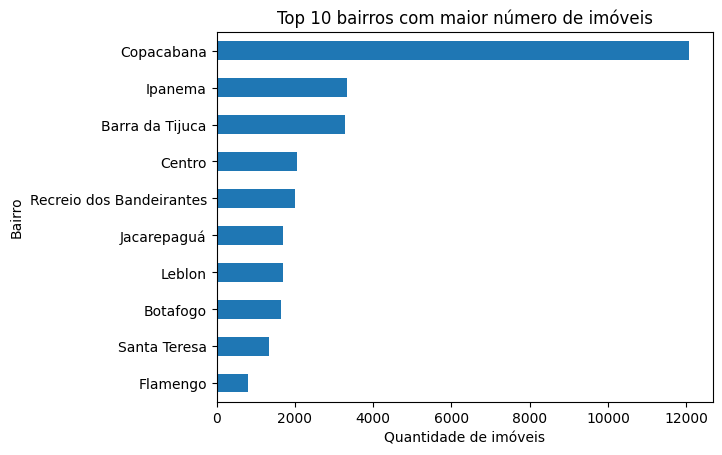

In [ ]:
import matplotlib.pyplot as plt

df['neighbourhood'].value_counts().head(10).sort_values().plot(kind='barh')

plt.title('Top 10 bairros com maior número de imóveis')
plt.xlabel('Quantidade de imóveis')
plt.ylabel('Bairro')

plt.show()

💡 Insight:

Observa-se que bairros como Copacabana, Ipanema e Barra da Tijuca concentram a maior quantidade de imóveis no Airbnb.

Essa concentração está associada à alta demanda turística e à infraestrutura dessas regiões, indicando mercados mais consolidados na plataforma.

Para complementar a análise de volume, foi avaliada a distribuição geográfica dos imóveis utilizando as coordenadas de latitude e longitude, permitindo visualizar a concentração espacial dos anúncios na cidade.

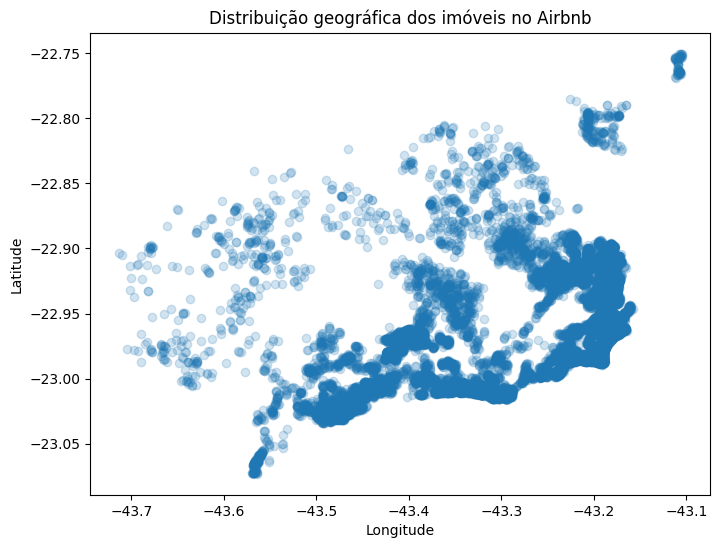

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['longitude'],
    df['latitude'],
    alpha=0.2
)

plt.title('Distribuição geográfica dos imóveis no Airbnb')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

💡 Insight:

Observa-se uma forte concentração de imóveis nas regiões litorâneas da cidade, especialmente na Zona Sul, com destaque para bairros como Copacabana, Ipanema e Leblon.

Além disso, é possível identificar a presença de polos relevantes na Zona Oeste, como Barra da Tijuca, indicando uma expansão da oferta para outras regiões além do eixo turístico tradicional.

### 📌 Qual a mediana de preço por bairro e como o volume de anúncios influencia esse valor?

Para responder a essa questão, analisamos a relação entre o preço mediano dos imóveis e a quantidade de anúncios por bairro.

In [ ]:
bairro_stats = df.groupby('neighbourhood').agg(
    mediana_preco=('price', 'median'),
    qtd_imoveis=('price', 'count')
).reset_index()

In [ ]:
bairro_stats = bairro_stats.sort_values(by='mediana_preco', ascending=False)
bairro_stats.head(10)

,neighbourhood,mediana_preco,qtd_imoveis
72,Joá,5250.0,159
2,Anchieta,2531.0,2
150,Zumbi,1323.0,1
67,Jacaré,855.0,3
31,Colégio,829.5,2
127,São Conrado,792.0,334
73,Lagoa,585.0,247
75,Leblon,572.0,1687
28,Cidade de Deus,540.0,10
0,Abolição,524.5,8


Observa-se que alguns bairros possuem uma quantidade muito baixa de imóveis, o que pode distorcer a análise do preço mediano.

Para reduzir esse efeito, será aplicado um filtro, considerando apenas bairros com mais de 50 imóveis.

In [ ]:
bairro_stats = bairro_stats[bairro_stats['qtd_imoveis'] > 50]
bairro_stats.head(10)

,neighbourhood,mediana_preco,qtd_imoveis
72,Joá,5250.0,159
127,São Conrado,792.0,334
73,Lagoa,585.0,247
75,Leblon,572.0,1687
63,Ipanema,517.0,3340
57,Gávea,484.0,223
7,Barra da Tijuca,467.0,3289
68,Jardim Botânico,415.5,192
35,Cosme Velho,360.0,71
60,Humaitá,333.5,178


In [ ]:
destaques = ['Copacabana', 'Leblon', 'Ipanema', 'Barra da Tijuca', 'Joá',
             'Lagoa', 'São Conrado']

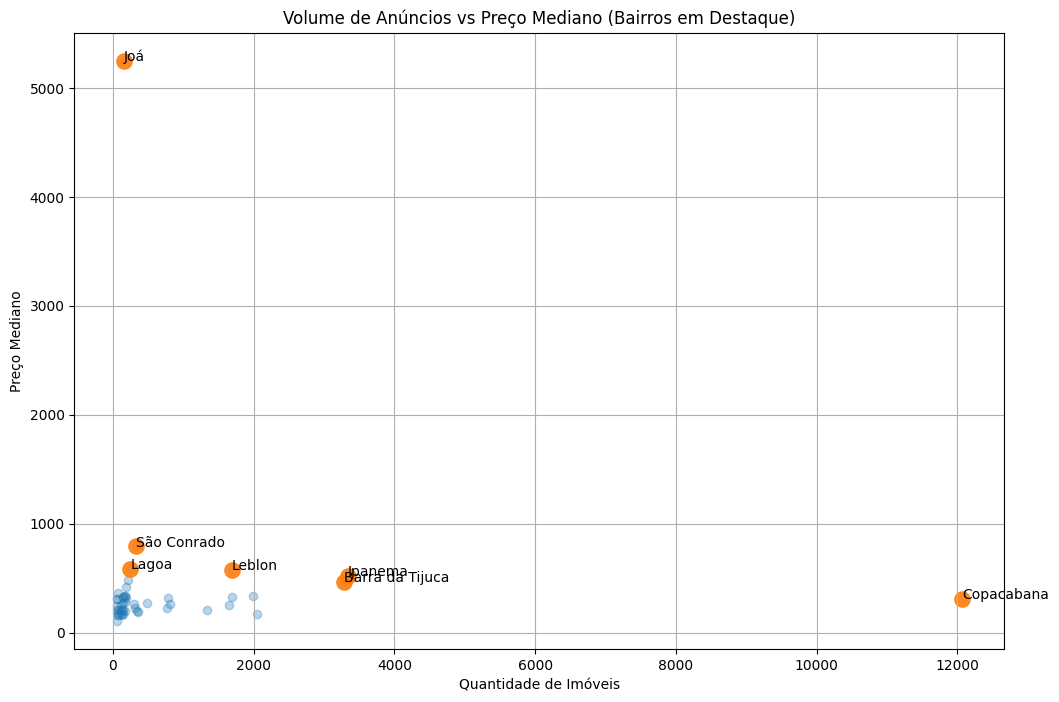

In [ ]:
# Gráfico
plt.figure(figsize=(12,8))

# Scatter geral (todos os bairros)
plt.scatter(
    bairro_stats['qtd_imoveis'],
    bairro_stats['mediana_preco'],
    alpha=0.3
)

# Scatter só dos destaques (mais visível)
destaque_df = bairro_stats[bairro_stats['neighbourhood'].isin(destaques)]

plt.scatter(
    destaque_df['qtd_imoveis'],
    destaque_df['mediana_preco'],
    s=120,  # bolinhas maiores
    alpha=0.9
)

# Adicionar nome nos destaques
for i, row in destaque_df.iterrows():
    plt.text(
        row['qtd_imoveis'],
        row['mediana_preco'],
        row['neighbourhood'],
        fontsize=10,
    )

plt.xlabel('Quantidade de Imóveis')
plt.ylabel('Preço Mediano')
plt.title('Volume de Anúncios vs Preço Mediano (Bairros em Destaque)')

plt.grid(True)
plt.show()

💡 Insight:

A análise mostra que não existe uma relação linear entre a quantidade de imóveis disponíveis e o preço mediano dos bairros.

Copacabana, por exemplo, apresenta o maior volume de anúncios, mas possui um preço mediano relativamente mais baixo, indicando que a alta oferta tende a gerar maior competitividade entre os anfitriões, reduzindo os preços.

Por outro lado, bairros como Leblon, Ipanema e Barra da Tijuca mantêm preços elevados mesmo com menor volume de imóveis, sugerindo que a localização e o perfil da demanda exercem maior influência sobre o valor do que a oferta em si.

Além disso, o bairro Joá se destaca como um outlier, com baixíssimo volume de anúncios, mas com preços significativamente mais altos, caracterizando um mercado de nicho e alto padrão.

Portanto, o equilíbrio entre oferta e preço não é direto: enquanto alta oferta pode pressionar preços para baixo, regiões premium conseguem sustentar valores elevados independentemente do volume.

### 📌 Qual é a tipologia de imóvel predominante em cada região?

Para responder a essa questão, analisamos a distribuição dos tipos de imóveis (room_type) em cada bairro, com o objetivo de identificar o perfil predominante de oferta em cada região.

In [ ]:
# 1. Lista de bairros
bairros_especificos = [ 'Joá', 'São Conrado', 'Lagoa', 'Leblon', 'Ipanema', 'Gávea', 'Barra da Tijuca', 'Jardim Botânico', 'Cosme Velho', 'Humaitá' ]

In [ ]:
# 2. Traduzir room_type
df['room_type'] = df['room_type'].replace({ 'Entire home/apt': 'Casa/Apartamento inteiro', 'Private room': 'Quarto privado', 'Shared room': 'Quarto compartilhado', 'Hotel room': 'Quarto de hotel' })

In [ ]:
# 3. Filtrar bairros
df_filtrado = df[df['neighbourhood'].isin(bairros_especificos)]

In [ ]:
# 4. Contagem
tipo_bairro = df_filtrado.groupby(['neighbourhood', 'room_type']).size().reset_index(name='qtd')

In [ ]:
# 5. Total por bairro
tipo_bairro['total_bairro'] = tipo_bairro.groupby('neighbourhood')['qtd'].transform('sum')

In [ ]:
# 6. Proporção
tipo_bairro['proporcao'] = tipo_bairro['qtd'] / tipo_bairro['total_bairro']

In [ ]:
# 7. Pivot
pivot = tipo_bairro.pivot( index='neighbourhood', columns='room_type', values='proporcao' ).fillna(0)

In [ ]:
# 8. Ordenar pelo tipo predominante (Casa/Apartamento inteiro)
pivot = pivot.sort_values(by='Casa/Apartamento inteiro', ascending=False)

In [ ]:
# 9. Cores
cores = ['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c']

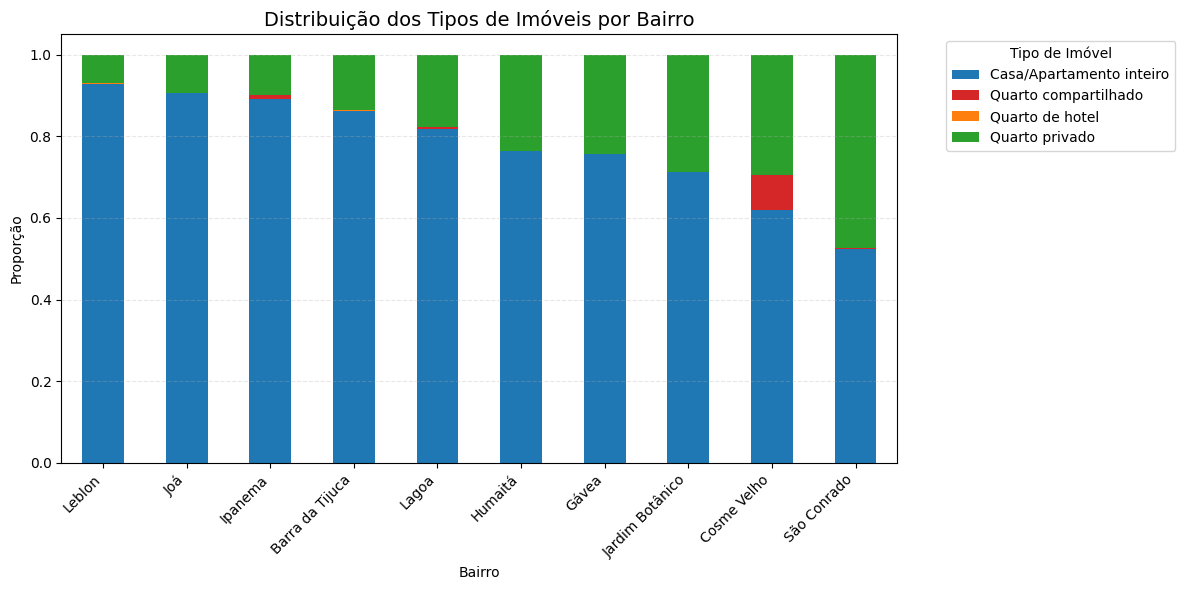

In [ ]:
# 10. Plot
pivot.plot( kind='bar', stacked=True, figsize=(12,6), color=cores )

# 11. Ajustes visuais
plt.title('Distribuição dos Tipos de Imóveis por Bairro', fontsize=14)
plt.xlabel('Bairro')
plt.ylabel('Proporção')
plt.xticks(rotation=45, ha='right')
plt.legend( title='Tipo de Imóvel', bbox_to_anchor=(1.05, 1), loc='upper left' )
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

💡 Insight:

A análise mostra que há uma predominância clara de imóveis do tipo "Casa/Apartamento inteiro" em todos os bairros analisados, especialmente em regiões de maior valor como Leblon, Joá e Ipanema, onde essa tipologia representa a maior parte da oferta.

Esse padrão indica que esses bairros estão fortemente orientados para locações completas, com foco em turismo ou estadias de maior valor, reforçando seu posicionamento como mercados premium.

Por outro lado, observa-se que bairros como São Conrado, Cosme Velho e Jardim Botânico apresentam maior diversidade de tipologias, com aumento na proporção de "Quarto privado". No entanto, essa diversificação não indica necessariamente um mercado mais acessível, mas sim uma adaptação da oferta.

Em regiões como São Conrado, essa característica pode estar associada à presença de imóveis de grande porte, como casas e coberturas, onde o aluguel de quartos privados funciona como uma estratégia de rentabilização de espaços ociosos. Além disso, o alto valor das locações completas pode restringir a demanda, tornando a locação parcial uma alternativa para ampliar o público.

A presença de "Quarto compartilhado" e "Quarto de hotel" é praticamente irrelevante na maioria dos bairros, indicando baixa representatividade desses formatos no mercado analisado.

Dessa forma, a tipologia dos imóveis reforça a segmentação do mercado: enquanto regiões premium concentram imóveis inteiros e mantêm seu posicionamento de alto valor, bairros com maior diversidade de tipologias refletem estratégias de flexibilização da oferta dentro de diferentes contextos de demanda e perfil imobiliário.

### 📌 Imóveis com mais avaliações tendem a ser mais baratos?

In [ ]:
df_filtrado = df[df['price'] < 5000]

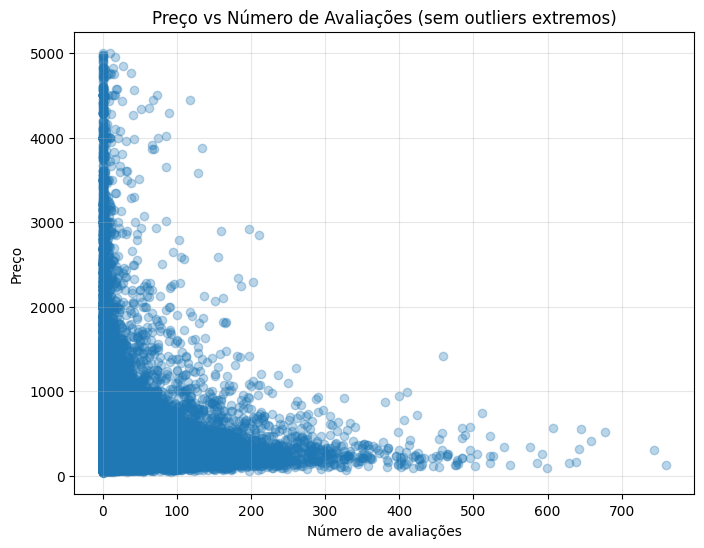

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_filtrado['number_of_reviews'],
    df_filtrado['price'],
    alpha=0.3
)

plt.title('Preço vs Número de Avaliações (sem outliers extremos)')
plt.xlabel('Número de avaliações')
plt.ylabel('Preço')

plt.grid(alpha=0.3)
plt.show()

💡 Insight:

Observa-se uma relação inversa entre preço e número de avaliações, indicando que imóveis mais baratos tendem a acumular maior volume de avaliações.

Esse comportamento sugere que imóveis com preços mais acessíveis possuem maior demanda e rotatividade, enquanto imóveis mais caros apresentam um perfil mais exclusivo, com menor frequência de reservas.

### 📌 Qual a disponibilidade média dos imóveis ao longo do ano por região?

In [ ]:
# base agregada
df_base = df.groupby('neighbourhood').agg(
    preco_mediano=('price', 'median'),
    quantidade=('price', 'count'),
    disponibilidade_media=('availability_365', 'mean')
)

In [ ]:
# filtro
df_filtrado = df_base[df_base['quantidade'] >= 50]

In [ ]:
# top 10 bairros mais caros
df_caros = df_filtrado.sort_values(by='preco_mediano', ascending=False).head(10)
df_caros['tipo'] = 'Mais caros'

In [ ]:
# top 10 bairros mais baratos
df_baratos = df_filtrado.sort_values(by='preco_mediano', ascending=True).head(10)
df_baratos['tipo'] = 'Mais baratos'

In [ ]:
# juntar bairros
df_plot = pd.concat([df_caros, df_baratos])

In [ ]:
# ordem do visual
df_plot = df_plot.sort_values(by='disponibilidade_media', ascending=False)

In [ ]:
# cores
cores = df_plot['tipo'].map({
    'Mais caros': 'orange',
    'Mais baratos': 'steelblue'
})

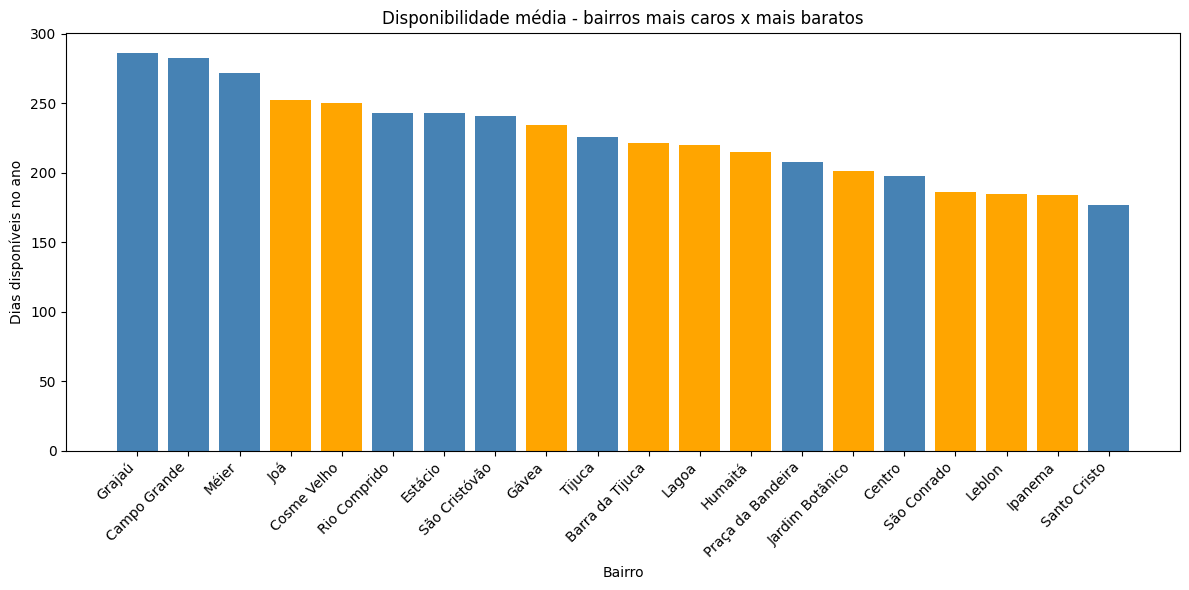

In [ ]:
# gráfico
plt.figure(figsize=(12,6))

plt.bar(
    df_plot.index,
    df_plot['disponibilidade_media'],
    color=cores
)

plt.title('Disponibilidade média - bairros mais caros x mais baratos')
plt.xlabel('Bairro')
plt.ylabel('Dias disponíveis no ano')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

💡 Insight:

A análise indica que não há uma diferença significativa na disponibilidade média entre bairros mais caros e mais baratos.

Isso sugere que o preço do imóvel não é, isoladamente, um fator determinante para a quantidade de dias disponíveis ao longo do ano.

Dessa forma, a ocupação dos imóveis pode estar mais relacionada a outros fatores, como localização, perfil do imóvel e demanda específica da região.

## ✅ Conclusão

- O mercado de Airbnb no Rio de Janeiro é fortemente concentrado na Zona Sul, com destaque para Copacabana, Ipanema e Leblon, além de apresentar expansão para a Zona Oeste, como Barra da Tijuca.

- Não há uma relação direta entre volume de anúncios e preço: bairros com maior oferta tendem a ser mais competitivos, enquanto regiões premium mantêm preços elevados mesmo com menor volume.

- A tipologia predominante é de imóveis inteiros, especialmente em bairros de alto padrão, reforçando o foco em locações completas e de maior valor.

- Imóveis mais baratos tendem a acumular maior número de avaliações, indicando maior demanda e rotatividade, enquanto imóveis mais caros apresentam um perfil mais exclusivo.

- A disponibilidade média não apresentou diferenças significativas entre bairros caros e baratos, sugerindo que a ocupação depende de múltiplos fatores além do preço.

- De forma geral, o mercado é influenciado por uma combinação de localização, oferta, tipologia e demanda, evidenciando diferentes perfis e estratégias dentro da plataforma.